# Fine-Tuning Notebook

This notebook fine-tunes a pre-trained model (`3nd_model_97percent.pth`) with a low learning rate.

**Purpose:**
- Load pre-trained model checkpoint
- Fine-tune on full training set (no validation)
- Use low learning rate (3e-4 or lower) to preserve model quality
- Save results to `fine_tune_results/` folder


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch import amp
from tqdm import tqdm
import importlib
import os
import json
from datetime import datetime

import models
importlib.reload(models)
from models import create_efficientnet_b3
import datasets
importlib.reload(datasets)
from datasets import CIFAR10BatchDataset300

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Create fine_tune_results directory if it doesn't exist
os.makedirs("generated_data/fine_tune_results", exist_ok=True)


Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti


## Configuration


In [ ]:
# Model checkpoint path
checkpoint_path = "generated_data/4th_model_98percent.pth"

# Fine-tuning hyperparameters
num_epochs = 10  # Single epoch for fine-tuning
batch_size = 128  # Increased from 64 for faster processing
learning_rate = 3e-4  # Low learning rate for fine-tuning
weight_decay = 0.0001  # Matching original
optimizer_type = "Adam"
scheduler_type = "CosineAnnealing"
label_smoothing = 0.05

# Model config
model_name = "efficientnet_b3"
image_size = 300

# Mixed precision
use_amp = True

# DataLoader config - Optimized for Windows
num_workers = 4  # Multiple workers for parallel data loading (matching Train_notebook)
pin_memory = True  # Faster GPU transfer
persistent_workers = False  # Disabled for Windows compatibility (avoids hangs)
prefetch_factor = 2  # Prefetch batches ahead (matching Train_notebook)

print(f"Checkpoint path: {checkpoint_path}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"DataLoader workers: {num_workers}")


Checkpoint path: generated_data/4th_model_98percent.pth
Learning rate: 0.0003
Epochs: 10
Batch size: 128
DataLoader workers: 6


## Load Dataset


In [ ]:
train_dataset = CIFAR10BatchDataset300(batch_dir="./cifar-10-batches-py")

print(f"Total training samples: {len(train_dataset)}")
print(f"Dataset classes: 10")

# Create DataLoader with optimized settings (Windows compatible)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=False,  # Disabled for Windows compatibility
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    drop_last=False  # Keep all data
)

print(f"DataLoader created: {len(train_loader)} batches")
print(f"Effective batch size: {batch_size}")
print(f"DataLoader workers: {num_workers}, Persistent: False (Windows compatibility), Prefetch: {prefetch_factor if num_workers > 0 else None}")


Total training samples: 50000
Dataset classes: 10
DataLoader created: 391 batches
Effective batch size: 128
DataLoader workers: 6, Persistent: True, Prefetch: 4


## Load Model and Training Setup


In [11]:
# Create model
print("Creating model...")
model = create_efficientnet_b3(num_classes=10).to(device)
model = model.to(memory_format=torch.channels_last)

# Load checkpoint
print(f"Loading checkpoint from {checkpoint_path}...")
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print("Model loaded successfully!")

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Create scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Loss and scaler
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
scaler = amp.GradScaler("cuda") if use_amp else None

print("Training setup complete!")


Creating model...
Loading checkpoint from generated_data/4th_model_98percent.pth...
Model loaded successfully!
Training setup complete!


## Training Function


In [12]:
def train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, use_amp, device, epoch_num=0):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    num_batches = len(train_loader)
    log_interval = max(1, num_batches // 10)  # Log every 10% of batches
    
    for step, (inputs, targets) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch_num+1}")):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        inputs = inputs.to(memory_format=torch.channels_last)
        
        optimizer.zero_grad(set_to_none=True)
        
        if use_amp:
            with amp.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        
        # Compute accuracy
        _, predicted = outputs.max(1)
        batch_size = targets.size(0)
        total += batch_size
        correct += predicted.eq(targets).sum().item()
        
        batch_loss = loss.detach().item()
        running_loss += batch_loss
        
        # Periodic logging
        if (step + 1) % log_interval == 0 or (step + 1) == num_batches:
            current_acc = correct / total
            avg_loss_so_far = running_loss / (step + 1)
            print(f"  Batch {step+1}/{num_batches} | Loss: {batch_loss:.4f} | Avg Loss: {avg_loss_so_far:.4f} | Acc: {current_acc:.4f}")
    
    scheduler.step()
    
    avg_loss = running_loss / num_batches
    accuracy = correct / total
    return avg_loss, accuracy

print("Training function defined!")


Training function defined!


## Fine-Tuning Loop


In [ ]:
import time

print("\n" + "="*60)
print("Starting Fine-Tuning")
print("="*60 + "\n")

train_losses = []
train_accuracies = []
epoch_times = []
start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*60}")
    print(f"Learning Rate: {current_lr:.6f}")
    print(f"Batches per epoch: {len(train_loader)}")
    
    avg_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, 
        optimizer, scheduler, scaler, use_amp, device, epoch
    )
    
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)
    elapsed_total = time.time() - start_time
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Time: {epoch_time:.2f}s ({epoch_time/60:.2f} min)")
    print(f"  Avg time per batch: {epoch_time/len(train_loader):.3f}s")
    print(f"  Total elapsed: {elapsed_total/60:.2f} min")
    
    if epoch > 0:
        loss_change = train_losses[-1] - train_losses[-2]
        acc_change = train_accuracies[-1] - train_accuracies[-2]
        print(f"  Loss change: {loss_change:+.4f}")
        print(f"  Accuracy change: {acc_change:+.4f} ({acc_change*100:+.2f}%)")
    
    if torch.cuda.is_available():
        memory_allocated = torch.cuda.memory_allocated(0) / 1024**3
        memory_reserved = torch.cuda.memory_reserved(0) / 1024**3
        print(f"  GPU Memory: {memory_allocated:.2f}GB / {memory_reserved:.2f}GB")

total_time = time.time() - start_time
print(f"\n{'='*60}")
print("Fine-tuning completed!")
print(f"{'='*60}")
print(f"Total training time: {total_time/60:.2f} min ({total_time:.2f}s)")
print(f"Average time per epoch: {np.mean(epoch_times):.2f}s")
print(f"Final Loss: {train_losses[-1]:.4f}")
print(f"Final Accuracy: {train_accuracies[-1]:.4f} ({train_accuracies[-1]*100:.2f}%)")
if len(train_losses) > 1:
    print(f"Loss improvement: {train_losses[0] - train_losses[-1]:.4f}")
    print(f"Accuracy improvement: {train_accuracies[-1] - train_accuracies[0]:.4f} ({((train_accuracies[-1] - train_accuracies[0])*100):+.2f}%)")



Starting Fine-Tuning


Epoch 1/10
Learning Rate: 0.000300
Batches per epoch: 391


Epoch 1:   0%|          | 1/391 [06:14<40:34:55, 374.60s/it]

## Save Results


Fine-tuned model saved to generated_data/fine_tune_results/fine_tuned_model.pth
Training info saved to generated_data/fine_tune_results/training_info.json


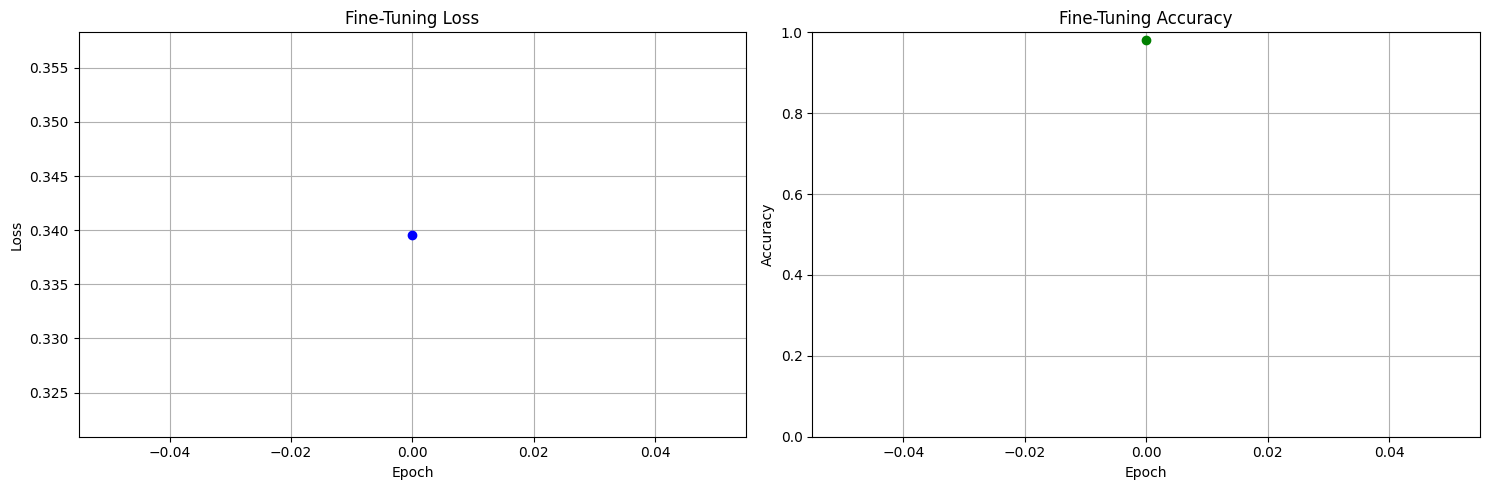

Training curves saved to generated_data/fine_tune_results/training_curve.png


In [ ]:
# Save fine-tuned model
model_path = "generated_data/fine_tune_results/fine_tuned_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Fine-tuned model saved to {model_path}")

# Save training info
training_info = {
    "timestamp": datetime.now().isoformat(),
    "checkpoint_source": checkpoint_path,
    "hyperparameters": {
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "optimizer": optimizer_type,
        "scheduler": scheduler_type,
        "label_smoothing": label_smoothing,
        "model": model_name,
        "image_size": image_size,
    },
    "training": {
        "train_losses": train_losses,
        "train_accuracies": train_accuracies if 'train_accuracies' in locals() else [],
        "epoch_times": epoch_times if 'epoch_times' in locals() else [],
        "final_loss": float(train_losses[-1]) if train_losses else None,
        "final_accuracy": float(train_accuracies[-1]) if 'train_accuracies' in locals() and train_accuracies else None,
        "total_time": float(total_time) if 'total_time' in locals() else None,
        "avg_epoch_time": float(np.mean(epoch_times)) if 'epoch_times' in locals() and epoch_times else None,
    }
}

info_path = "generated_data/fine_tune_results/training_info.json"
with open(info_path, "w") as f:
    json.dump(training_info, f, indent=4)

print(f"Training info saved to {info_path}")

# Plot training curves
if len(train_losses) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curve
    ax1.plot(train_losses, marker='o', color='blue')
    ax1.set_title("Fine-Tuning Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True)
    
    # Accuracy curve
    if 'train_accuracies' in locals() and len(train_accuracies) > 0:
        ax2.plot(train_accuracies, marker='o', color='green')
        ax2.set_title("Fine-Tuning Accuracy")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Accuracy")
        ax2.grid(True)
        ax2.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig("generated_data/fine_tune_results/training_curve.png", dpi=150)
    plt.show()
    print("Training curves saved to generated_data/fine_tune_results/training_curve.png")
